In [1]:
# ============================================================
# LOAD PREPROCESSED DATA
# ============================================================

import pandas as pd
import numpy as np
from collections import Counter

# Load preprocessed train and test data
X_train_final = pd.read_parquet('../data/cleaned/X_train_preprocessed.parquet')
X_test_final = pd.read_parquet('../data/cleaned/X_test_preprocessed.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print("="*70)
print("DATA LOADED SUCCESSFULLY")
print("="*70)
print(f"✓ X_train shape: {X_train_final.shape}")
print(f"✓ X_test shape: {X_test_final.shape}")
print(f"✓ y_train shape: {y_train.shape}")
print(f"✓ y_test shape: {y_test.shape}")

DATA LOADED SUCCESSFULLY
✓ X_train shape: (103986, 40)
✓ X_test shape: (25997, 40)
✓ y_train shape: (103986,)
✓ y_test shape: (25997,)


In [2]:
# ============================================================
# TARGET VARIABLE ANALYSIS
# ============================================================

print("\n" + "="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)

train_counts = Counter(y_train)
test_counts = Counter(y_test)

print(f"\nTrain target distribution:")
for label, count in sorted(train_counts.items()):
    pct = (count / len(y_train)) * 100
    print(f"  Class {label}: {count:,} ({pct:.2f}%)")

print(f"\nTest target distribution:")
for label, count in sorted(test_counts.items()):
    pct = (count / len(y_test)) * 100
    print(f"  Class {label}: {count:,} ({pct:.2f}%)")

# Calculate imbalance ratio
minority_class = min(train_counts, key=train_counts.get)
majority_class = max(train_counts, key=train_counts.get)
imbalance_ratio = train_counts[majority_class] / train_counts[minority_class]

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Minority class ({minority_class}): {train_counts[minority_class]:,} samples")
print(f"Majority class ({majority_class}): {train_counts[majority_class]:,} samples")


TARGET VARIABLE ANALYSIS

Train target distribution:
  Class 0: 17,178 (16.52%)
  Class 1: 86,808 (83.48%)

Test target distribution:
  Class 0: 4,295 (16.52%)
  Class 1: 21,702 (83.48%)

Imbalance ratio: 5.05:1
Minority class (0): 17,178 samples
Majority class (1): 86,808 samples


In [8]:
X_train_final.dtypes


provider_code             category
year                      category
age_band                  category
gender                     float64
t0_assisted                float64
t0_assisted_by               uint8
t0_symptom_period          float64
t0_previous_surgery        float64
t0_living_arrangements    category
t0_disability              float64
heart_disease                int64
high_bp                      int64
stroke                       int64
circulation                  int64
lung_disease                 int64
diabetes                     int64
kidney_disease               int64
nervous_system               int64
liver_disease                int64
cancer                       int64
depression                   int64
arthritis                    int64
t0_mobility                float64
t0_self_care               float64
t0_activity                float64
t0_discomfort              float64
t0_anxiety                 float64
oks_t0_pain                  uint8
oks_t0_night_pain   

## Extra Feature Engineering

### Academic Hospitals vs Non Academic hospitals

Since university hospitals can deal with worse/more advanced cases, the provider codes are transformed based on their status

In [11]:
# Read data from proms_providers_academic_categories.xlsx

proms_academic_df = pd.read_excel('../data/supporting/proms_providers_academic_categories.xlsx')

proms_academic_df.head()

# Transform academisch/niet academisch to 1/0
proms_academic_df['University Hospital'] = proms_academic_df['category'].map({'academisch': 1, 'niet-academisch': 0})
proms_academic_df.head(50)

# Merge with X_train_final and X_test_final
X_train_final = X_train_final.merge(proms_academic_df[['provider_code', 'University Hospital']], on='provider_code', how='left')
X_test_final = X_test_final.merge(proms_academic_df[['provider_code', 'University Hospital']], on='provider_code', how='left')

X_train_final['University Hospital'].value_counts()
X_test_final['University Hospital'].value_counts()

0    20353
1     5644
Name: University Hospital, dtype: int64

In [13]:
X_train_final.head()

,provider_code,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,...,oks_t0_walking,oks_t0_standing,oks_t0_limping,oks_t0_kneeling,oks_t0_work,oks_t0_confidence,oks_t0_shopping,oks_t0_stairs,oks_t0_score,University Hospital
0,RTH,2017/18,4,0.0,0.0,0,4.0,0.0,1.0,0.0,...,1,2,3,1,3,0,4,2,26.0,1
1,RN5,2017/18,5,1.0,0.0,0,2.0,0.0,2.0,1.0,...,2,3,1,0,0,0,2,1,19.0,0
2,RQ8,2017/18,4,1.0,0.0,0,2.0,0.0,1.0,1.0,...,2,3,0,2,2,3,3,2,24.0,0
3,RBT,2016/17,5,0.0,0.0,0,2.0,0.0,1.0,0.0,...,2,1,1,1,1,1,1,1,12.0,0
4,NVC23,2016/17,3,1.0,0.0,0,2.0,0.0,1.0,0.0,...,2,3,2,2,2,2,2,2,26.0,0


Analyze the distribution between number of surgeries (size of hospitals) and scores they have achieved and document whether there is a pattern

In [41]:
# Extract top 10 most common provider codes with their value counts and how much they appear in the training set (% wise of total)
top_50_providers = X_train_final['provider_code'].value_counts().nsmallest(50).index.tolist()

for provider in top_50_providers:
    count = X_train_final['provider_code'].value_counts()[provider]
    pct = (count / len(X_train_final)) * 100
    print(f"Provider Code: {provider}, Count: {count}, Percentage of Training Set: {pct:.2f}%")
# ============================================================

Provider Code: RJ7, Count: 3, Percentage of Training Set: 0.00%
Provider Code: NT343, Count: 8, Percentage of Training Set: 0.01%
Provider Code: NYW01, Count: 9, Percentage of Training Set: 0.01%
Provider Code: NT30A, Count: 9, Percentage of Training Set: 0.01%
Provider Code: NT310, Count: 10, Percentage of Training Set: 0.01%
Provider Code: NFH01, Count: 10, Percentage of Training Set: 0.01%
Provider Code: NT455, Count: 10, Percentage of Training Set: 0.01%
Provider Code: NVC0R, Count: 15, Percentage of Training Set: 0.01%
Provider Code: NT241, Count: 17, Percentage of Training Set: 0.02%
Provider Code: NT416, Count: 17, Percentage of Training Set: 0.02%
Provider Code: NT315, Count: 17, Percentage of Training Set: 0.02%
Provider Code: NQM01, Count: 18, Percentage of Training Set: 0.02%
Provider Code: NT308, Count: 19, Percentage of Training Set: 0.02%
Provider Code: NT211, Count: 22, Percentage of Training Set: 0.02%
Provider Code: NT205, Count: 22, Percentage of Training Set: 0.02%
P

In [17]:
# ============================================================
# ONE-HOT ENCODE CATEGORICAL VARIABLES
# ============================================================

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import joblib

# Define categorical columns to encode
categorical_columns = [
    'year', 'age_band', 
    't0_living_arrangements'
]

print("="*70)
print("ONE-HOT ENCODING CATEGORICAL VARIABLES")
print("="*70)

# Check which categorical columns exist in the data
existing_categorical = [col for col in categorical_columns if col in X_train_final.columns]
print(f"\nCategorical columns found: {existing_categorical}")

# ============================================================
# FIT ONE-HOT ENCODER ON TRAINING DATA
# ============================================================

# Initialize encoder
encoder = OneHotEncoder(
    drop='first',           # Drop first category to avoid multicollinearity
    sparse_output=False,    # Return dense array (easier to work with)
    handle_unknown='ignore' # Ignore unknown categories in test set
)

# Fit on training data
print(f"\n✓ Fitting encoder on training data...")
encoder.fit(X_train_final[existing_categorical])

# Get feature names for encoded columns
encoded_feature_names = encoder.get_feature_names_out(existing_categorical)
print(f"✓ Encoder fitted - will create {len(encoded_feature_names)} one-hot encoded features")

# ============================================================
# TRANSFORM TRAINING DATA
# ============================================================

print(f"\n✓ Transforming training data...")

# Transform categorical columns
X_train_encoded = encoder.transform(X_train_final[existing_categorical])

# Create DataFrame with encoded features
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train_final.index
)

# Drop original categorical columns and add encoded ones
X_train_numerical = X_train_final.drop(columns=existing_categorical)
X_train_final_encoded = pd.concat([X_train_numerical, X_train_encoded_df], axis=1)

print(f"✓ Training data shape before encoding: {X_train_final.shape}")
print(f"✓ Training data shape after encoding: {X_train_final_encoded.shape}")

# ============================================================
# TRANSFORM TEST DATA
# ============================================================

print(f"\n✓ Transforming test data...")

# Transform categorical columns (using fitted encoder)
X_test_encoded = encoder.transform(X_test_final[existing_categorical])

# Create DataFrame with encoded features
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test_final.index
)

# Drop original categorical columns and add encoded ones
X_test_numerical = X_test_final.drop(columns=existing_categorical)
X_test_final_encoded = pd.concat([X_test_numerical, X_test_encoded_df], axis=1)

print(f"✓ Test data shape before encoding: {X_test_final.shape}")
print(f"✓ Test data shape after encoding: {X_test_final_encoded.shape}")

# ============================================================
# VERIFICATION
# ============================================================

print("\n" + "="*70)
print("ENCODING VERIFICATION")
print("="*70)

print(f"\n✓ X_train_final_encoded shape: {X_train_final_encoded.shape}")
print(f"✓ X_test_final_encoded shape: {X_test_final_encoded.shape}")
print(f"✓ Both datasets have same number of features: {X_train_final_encoded.shape[1] == X_test_final_encoded.shape[1]}")

# Check for missing values
print(f"\n✓ Missing values in X_train_final_encoded: {X_train_final_encoded.isna().sum().sum()}")
print(f"✓ Missing values in X_test_final_encoded: {X_test_final_encoded.isna().sum().sum()}")

# Show sample of new columns
print("\n" + "="*70)
print("SAMPLE OF ONE-HOT ENCODED FEATURES")
print("="*70)

# Show first few encoded feature names for each original categorical variable
for original_col in existing_categorical:
    encoded_cols = [col for col in encoded_feature_names if col.startswith(original_col)]
    print(f"\n{original_col} → {len(encoded_cols)} one-hot features:")
    print(f"  Sample: {encoded_cols[:5]}")

# Show data sample
print("\n" + "="*70)
print("DATA PREVIEW (First 5 rows, first 10 columns)")
print("="*70)
print(X_train_final_encoded.iloc[:5, :10])

# ============================================================
# SAVE ENCODED DATA (Optional)
# ============================================================

print("\n" + "="*70)
print("SAVING ENCODED DATA")
print("="*70)

# Save encoded datasets
X_train_final_encoded.to_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet', index=False)
X_test_final_encoded.to_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet', index=False)

# Save encoder for future use
joblib.dump(encoder, '../data/cleaned/onehot_encoder_wo_provider.pkl')

print("✓ X_train_final_encoded saved to '../data/cleaned/X_train_encoded.parquet'")
print("✓ X_test_final_encoded saved to '../data/cleaned/X_test_encoded.parquet'")
print("✓ OneHotEncoder saved to '../data/cleaned/onehot_encoder.pkl'")

# ============================================================
# FEATURE COUNTS BY TYPE
# ============================================================

print("\n" + "="*70)
print("FEATURE BREAKDOWN")
print("="*70)

# Count features by original type
numerical_features = X_train_numerical.columns.tolist()
encoded_features = encoded_feature_names.tolist()

print(f"\nNumerical features (unchanged): {len(numerical_features)}")
print(f"One-hot encoded features (new): {len(encoded_features)}")
print(f"Total features: {len(X_train_final_encoded.columns)}")

print("\n" + "="*70)
print("✓ ONE-HOT ENCODING COMPLETE - DATA READY FOR MODELING")
print("="*70)

# ============================================================
# How to load encoder and apply to new data later:
# ============================================================
"""
# Load the fitted encoder
encoder = joblib.load('../data/processed/onehot_encoder.pkl')

# Apply to new data
X_new_encoded = encoder.transform(X_new[existing_categorical])
X_new_encoded_df = pd.DataFrame(
    X_new_encoded,
    columns=encoder.get_feature_names_out(existing_categorical),
    index=X_new.index
)
X_new_numerical = X_new.drop(columns=existing_categorical)
X_new_final = pd.concat([X_new_numerical, X_new_encoded_df], axis=1)
"""

ONE-HOT ENCODING CATEGORICAL VARIABLES

Categorical columns found: ['year', 'age_band', 't0_living_arrangements']

✓ Fitting encoder on training data...
✓ Encoder fitted - will create 7 one-hot encoded features

✓ Transforming training data...
✓ Training data shape before encoding: (103986, 41)
✓ Training data shape after encoding: (103986, 45)

✓ Transforming test data...
✓ Test data shape before encoding: (25997, 41)
✓ Test data shape after encoding: (25997, 45)

ENCODING VERIFICATION

✓ X_train_final_encoded shape: (103986, 45)
✓ X_test_final_encoded shape: (25997, 45)
✓ Both datasets have same number of features: True

✓ Missing values in X_train_final_encoded: 0
✓ Missing values in X_test_final_encoded: 0

SAMPLE OF ONE-HOT ENCODED FEATURES

year → 2 one-hot features:
  Sample: ['year_2017/18', 'year_2018/19']

age_band → 3 one-hot features:
  Sample: ['age_band_3', 'age_band_4', 'age_band_5']

t0_living_arrangements → 2 one-hot features:
  Sample: ['t0_living_arrangements_2.0', '

"\n# Load the fitted encoder\nencoder = joblib.load('../data/processed/onehot_encoder.pkl')\n\n# Apply to new data\nX_new_encoded = encoder.transform(X_new[existing_categorical])\nX_new_encoded_df = pd.DataFrame(\n    X_new_encoded,\n    columns=encoder.get_feature_names_out(existing_categorical),\n    index=X_new.index\n)\nX_new_numerical = X_new.drop(columns=existing_categorical)\nX_new_final = pd.concat([X_new_numerical, X_new_encoded_df], axis=1)\n"

📊 Modeling Guide – Where to Start

🎯 1. Problem Summary
- Task: Binary classification
- Target: oks_target_variable (whether patient improvement > 7 points)
- Class Imbalance: ~5:1 ratio (majority class dominates)
- Data: Fully preprocessed, no missing values, ready for modeling

🔧 2. Handling Class Imbalance
- You have several options:
✅ Option A: Class Weights (Recommended first approach)

- Use class_weight='balanced' in your classifier
- No need to modify data
- Works with: LogisticRegression, RandomForest, XGBoost, etc.

✅ Option B: Resampling (SMOTE)

- Apply SMOTE only to training data inside cross-validation
- Use imblearn.pipeline.Pipeline to prevent data leakage
- Best for smaller datasets

✅ Option C: Threshold Tuning

- Train normally, then adjust decision threshold
- Optimize for your preferred metric (F1, recall, precision)


📈 3. Evaluation Metrics
Given class imbalance, DO NOT rely solely on accuracy. Focus on:
Primary Metrics

- F1-Score (balance between precision and recall)
- ROC-AUC (overall discrimination ability)
- Precision-Recall AUC (better for imbalanced data)

Secondary Metrics

- Recall (if you want to catch all positive cases)
- Precision (if false positives are costly)
- Confusion Matrix (understand errors)


🧪 4. Model Selection Strategy
Baseline Models (Start here)

- Logistic Regression (class_weight='balanced')
- Random Forest (class_weight='balanced')
- Dummy Classifier (minimum performance)

Advanced Models (After baseline)

- XGBoost or LightGBM (handle categorical features well)
- CatBoost (native categorical support)
- Ensemble methods (stacking, voting)


🔄 5. Cross-Validation Strategy

- Use StratifiedKFold (5–10 folds)
- Maintains class distribution in each fold
- Report mean ± std of metrics

Important:

- If using SMOTE, apply it inside each CV fold
- Use imblearn.pipeline.Pipeline to prevent leakage


🎛️ 6. Hyperparameter Tuning
- Step 1: Train baseline models with default parameters
- Step 2: Use GridSearchCV or RandomizedSearchCV
- Step 3: Focus on models that performed best in baseline
Key Parameters to Tune
Random Forest
- Plain Textn_estimators: [100, 200, 500]max_depth: [10, 20, None]min_samples_split: [2, 5, 10]class_weight: ['balanced']Show more lines
XGBoost
- Plain Textn_estimators: [100, 200, 500]learning_rate: [0.01, 0.1, 0.3]max_depth: [3, 5, 7]scale_pos_weight: [calculated from class ratio]Show more lines

📊 7. Feature Engineering (Optional)

Feature Interactions:
- Example: age_band * heart_disease
Feature Selection:
- Use feature importance from tree-based models
- Try Recursive Feature Elimination (RFE)
Categorical Encoding:

- One-Hot Encoding for low-cardinality features
- Target Encoding for high-cardinality features (e.g., provider_code)

⚠️ 8. Important Reminders
- ✅ Use stratified cross-validation
- ✅ Focus on F1/ROC-AUC, not just accuracy
- ✅ Handle class imbalance (class weights or SMOTE)
- ✅ Evaluate on test set ONLY ONCE at the end
- ✅ Save your best model with joblib
- ❌ Touch the test set during model development
- ❌ Use SMOTE before train-test split
- ❌ Rely on accuracy alone for imbalanced data
- ❌ Forget to set random_state for reproducibility
- ❌ Oversample test data

# Encoded data

In [18]:
# Load encoded data

X_train_final_encoded = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
print("✓ Encoded data loaded successfully")

✓ Encoded data loaded successfully


In [19]:
X_train_final_encoded.head(5)

,provider_code,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,...,oks_t0_stairs,oks_t0_score,University Hospital,year_2017/18,year_2018/19,age_band_3,age_band_4,age_band_5,t0_living_arrangements_2.0,t0_living_arrangements_4.0
0,RTH,0.0,0.0,0,4.0,0.0,0.0,0,1,0,...,2,26.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,RN5,1.0,0.0,0,2.0,0.0,1.0,0,1,0,...,1,19.0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,RQ8,1.0,0.0,0,2.0,0.0,1.0,0,1,0,...,2,24.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,RBT,0.0,0.0,0,2.0,0.0,0.0,1,1,0,...,1,12.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,NVC23,1.0,0.0,0,2.0,0.0,0.0,0,1,0,...,2,26.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [27]:
# Drop provider_code
X_train_final_encoded = X_train_final_encoded.drop(columns=['provider_code'])
X_train_final_encoded.head(5)

,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,circulation,...,oks_t0_stairs,oks_t0_score,University Hospital,year_2017/18,year_2018/19,age_band_3,age_band_4,age_band_5,t0_living_arrangements_2.0,t0_living_arrangements_4.0
0,0.0,0.0,0,4.0,0.0,0.0,0,1,0,0,...,2,26.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0,2.0,0.0,1.0,0,1,0,0,...,1,19.0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0,2.0,0.0,1.0,0,1,0,0,...,2,24.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0,2.0,0.0,0.0,1,1,0,0,...,1,12.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0,2.0,0.0,0.0,0,1,0,0,...,2,26.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [28]:
# ============================================================================
# LOGISTIC REGRESSION WITH CLASS WEIGHTS AND 5-FOLD CROSS-VALIDATION
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    make_scorer
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("LOGISTIC REGRESSION WITH CLASS WEIGHTS - 5-FOLD CROSS-VALIDATION")
print("="*80)

# ============================================================================
# 1. CALCULATE CLASS WEIGHTS
# ============================================================================

print("\n📊 STEP 1: CALCULATING CLASS WEIGHTS")
print("-" * 80)

# Get class distribution
unique_classes = np.unique(y_train)
class_counts = np.bincount(y_train)

print(f"Class distribution:")
for cls in unique_classes:
    count = class_counts[cls]
    pct = (count / len(y_train)) * 100
    print(f"  Class {cls}: {count:,} ({pct:.2f}%)")

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

# Create class weight dictionary
class_weight_dict = {cls: weight for cls, weight in zip(unique_classes, class_weights)}

print(f"\nCalculated class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

print(f"\nWeight ratio: {class_weight_dict[0] / class_weight_dict[1]:.2f}:1")
print("✓ Class weights will penalize errors on minority class more heavily")

LOGISTIC REGRESSION WITH CLASS WEIGHTS - 5-FOLD CROSS-VALIDATION

📊 STEP 1: CALCULATING CLASS WEIGHTS
--------------------------------------------------------------------------------
Class distribution:
  Class 0: 17,178 (16.52%)
  Class 1: 86,808 (83.48%)

Calculated class weights:
  Class 0: 3.0267
  Class 1: 0.5989

Weight ratio: 5.05:1
✓ Class weights will penalize errors on minority class more heavily


In [30]:
# ============================================================================
# 2. INITIALIZE LOGISTIC REGRESSION MODEL
# ============================================================================

print("\n🔧 STEP 2: INITIALIZING LOGISTIC REGRESSION MODEL")
print("-" * 80)

# Create logistic regression model with class weights
lr_model = LogisticRegression(
    class_weight='balanced',  # Automatically handle class imbalance
    max_iter=1000,           # Increase iterations for convergence
    random_state=42,         # For reproducibility
    solver='lbfgs',          # Good for small to medium datasets
    n_jobs=-1                # Use all CPU cores
)

print("Model parameters:")
print(f"  ✓ Class weight: balanced")
print(f"  ✓ Max iterations: 1000")
print(f"  ✓ Solver: lbfgs")
print(f"  ✓ Random state: 42")


🔧 STEP 2: INITIALIZING LOGISTIC REGRESSION MODEL
--------------------------------------------------------------------------------
Model parameters:
  ✓ Class weight: balanced
  ✓ Max iterations: 1000
  ✓ Solver: lbfgs
  ✓ Random state: 42


In [31]:

# ============================================================================
# 3. DEFINE CROSS-VALIDATION STRATEGY
# ============================================================================

print("\n🔄 STEP 3: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION")
print("-" * 80)

# Use StratifiedKFold to maintain class distribution in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(f"  ✓ Number of folds: 5")
print(f"  ✓ Stratified: Yes (maintains class distribution)")
print(f"  ✓ Shuffle: Yes")
print(f"  ✓ Random state: 42")

# Verify class distribution in each fold
print("\nClass distribution verification across folds:")
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_final_encoded, y_train), 1):
    y_fold = y_train.iloc[val_idx]
    class_0_pct = (y_fold == 0).sum() / len(y_fold) * 100
    class_1_pct = (y_fold == 1).sum() / len(y_fold) * 100
    print(f"  Fold {fold_idx}: Class 0: {class_0_pct:.2f}% | Class 1: {class_1_pct:.2f}%")


🔄 STEP 3: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION
--------------------------------------------------------------------------------
Cross-validation strategy:
  ✓ Number of folds: 5
  ✓ Stratified: Yes (maintains class distribution)
  ✓ Shuffle: Yes
  ✓ Random state: 42

Class distribution verification across folds:
  Fold 1: Class 0: 16.52% | Class 1: 83.48%
  Fold 2: Class 0: 16.52% | Class 1: 83.48%
  Fold 3: Class 0: 16.52% | Class 1: 83.48%
  Fold 4: Class 0: 16.52% | Class 1: 83.48%
  Fold 5: Class 0: 16.52% | Class 1: 83.48%


In [32]:
# ============================================================================
# 4. DEFINE SCORING METRICS
# ============================================================================

print("\n📈 STEP 4: DEFINING EVALUATION METRICS")
print("-" * 80)

# Define multiple scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision_recall_auc': 'average_precision'  # PR-AUC, better for imbalanced data
}

print("Metrics to evaluate:")
for metric_name in scoring.keys():
    print(f"  ✓ {metric_name}")


📈 STEP 4: DEFINING EVALUATION METRICS
--------------------------------------------------------------------------------
Metrics to evaluate:
  ✓ accuracy
  ✓ precision
  ✓ recall
  ✓ f1
  ✓ roc_auc
  ✓ precision_recall_auc


In [33]:

# ============================================================================
# 5. PERFORM CROSS-VALIDATION
# ============================================================================

print("\n⚙️ STEP 5: RUNNING 5-FOLD CROSS-VALIDATION")
print("-" * 80)
print("This may take a few moments...\n")

# Perform cross-validation
cv_results = cross_validate(
    estimator=lr_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

print("✓ Cross-validation complete!")


⚙️ STEP 5: RUNNING 5-FOLD CROSS-VALIDATION
--------------------------------------------------------------------------------
This may take a few moments...

✓ Cross-validation complete!


In [34]:
# ============================================================================
# 6. DISPLAY RESULTS
# ============================================================================

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*80)

# Create results DataFrame
results_df = pd.DataFrame({
    'Metric': [],
    'Train Mean': [],
    'Train Std': [],
    'Val Mean': [],
    'Val Std': []
})

for metric_name in scoring.keys():
    train_scores = cv_results[f'train_{metric_name}']
    val_scores = cv_results[f'test_{metric_name}']
    
    results_df = pd.concat([results_df, pd.DataFrame({
        'Metric': [metric_name.upper()],
        'Train Mean': [train_scores.mean()],
        'Train Std': [train_scores.std()],
        'Val Mean': [val_scores.mean()],
        'Val Std': [val_scores.std()]
    })], ignore_index=True)

# Display results table
print("\n" + results_df.to_string(index=False))


CROSS-VALIDATION RESULTS (5-FOLD)

              Metric  Train Mean  Train Std  Val Mean  Val Std
            ACCURACY    0.671261   0.001444  0.670359 0.002171
           PRECISION    0.900684   0.000504  0.900296 0.002764
              RECALL    0.681337   0.001519  0.680502 0.002521
                  F1    0.775804   0.001150  0.775113 0.001600
             ROC_AUC    0.708330   0.001705  0.706974 0.006713
PRECISION_RECALL_AUC    0.913804   0.000587  0.913220 0.002249


In [35]:
# ============================================================================
# 7. DETAILED METRIC ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("DETAILED METRIC ANALYSIS")
print("="*80)

for metric_name in scoring.keys():
    train_scores = cv_results[f'train_{metric_name}']
    val_scores = cv_results[f'test_{metric_name}']
    
    print(f"\n{metric_name.upper()}:")
    print(f"  Training:   {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Validation: {val_scores.mean():.4f} ± {val_scores.std():.4f}")
    print(f"  Fold scores: {[f'{score:.4f}' for score in val_scores]}")
    
    # Check for overfitting
    gap = train_scores.mean() - val_scores.mean()
    if gap > 0.05:
        print(f"  ⚠️ Warning: Train-val gap = {gap:.4f} (possible overfitting)")
    else:
        print(f"  ✓ Train-val gap = {gap:.4f} (good)")


DETAILED METRIC ANALYSIS

ACCURACY:
  Training:   0.6713 ± 0.0014
  Validation: 0.6704 ± 0.0022
  Fold scores: ['0.6721', '0.6706', '0.6732', '0.6674', '0.6685']
  ✓ Train-val gap = 0.0009 (good)

PRECISION:
  Training:   0.9007 ± 0.0005
  Validation: 0.9003 ± 0.0028
  Fold scores: ['0.9031', '0.8964', '0.9031', '0.8976', '0.9012']
  ✓ Train-val gap = 0.0004 (good)

RECALL:
  Training:   0.6813 ± 0.0015
  Validation: 0.6805 ± 0.0025
  Fold scores: ['0.6803', '0.6845', '0.6817', '0.6789', '0.6771']
  ✓ Train-val gap = 0.0008 (good)

F1:
  Training:   0.7758 ± 0.0012
  Validation: 0.7751 ± 0.0016
  Fold scores: ['0.7760', '0.7763', '0.7769', '0.7731', '0.7733']
  ✓ Train-val gap = 0.0007 (good)

ROC_AUC:
  Training:   0.7083 ± 0.0017
  Validation: 0.7070 ± 0.0067
  Fold scores: ['0.7126', '0.6957', '0.7148', '0.7047', '0.7072']
  ✓ Train-val gap = 0.0014 (good)

PRECISION_RECALL_AUC:
  Training:   0.9138 ± 0.0006
  Validation: 0.9132 ± 0.0022
  Fold scores: ['0.9137', '0.9094', '0.9163'

In [36]:
# ============================================================================
# 8. KEY INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

val_f1 = cv_results['test_f1'].mean()
val_roc_auc = cv_results['test_roc_auc'].mean()
val_precision = cv_results['test_precision'].mean()
val_recall = cv_results['test_recall'].mean()
val_accuracy = cv_results['test_accuracy'].mean()

print(f"\n✓ Primary Metrics:")
print(f"  • F1-Score: {val_f1:.4f} (balance between precision and recall)")
print(f"  • ROC-AUC: {val_roc_auc:.4f} (overall discrimination ability)")

print(f"\n✓ Performance Breakdown:")
print(f"  • Accuracy: {val_accuracy:.4f}")
print(f"  • Precision: {val_precision:.4f} (how many predicted positives are correct)")
print(f"  • Recall: {val_recall:.4f} (how many actual positives we catch)")

print(f"\n💡 Interpretation:")
if val_f1 > 0.7:
    print(f"  ✓ Excellent F1-score ({val_f1:.4f}) - model performs well")
elif val_f1 > 0.5:
    print(f"  ✓ Good F1-score ({val_f1:.4f}) - model shows promise")
else:
    print(f"  ⚠️ Low F1-score ({val_f1:.4f}) - model may need improvement")

if val_roc_auc > 0.8:
    print(f"  ✓ Excellent ROC-AUC ({val_roc_auc:.4f}) - strong discriminative ability")
elif val_roc_auc > 0.7:
    print(f"  ✓ Good ROC-AUC ({val_roc_auc:.4f}) - decent discriminative ability")
else:
    print(f"  ⚠️ Low ROC-AUC ({val_roc_auc:.4f}) - weak discriminative ability")

# Check class weight effectiveness
if val_recall > 0.6:
    print(f"  ✓ Class weights working well (recall = {val_recall:.4f})")
else:
    print(f"  ⚠️ Consider adjusting class weights (recall = {val_recall:.4f})")

print("\n" + "="*80)
print("✓ CROSS-VALIDATION COMPLETE")
print("="*80)


KEY INSIGHTS

✓ Primary Metrics:
  • F1-Score: 0.7751 (balance between precision and recall)
  • ROC-AUC: 0.7070 (overall discrimination ability)

✓ Performance Breakdown:
  • Accuracy: 0.6704
  • Precision: 0.9003 (how many predicted positives are correct)
  • Recall: 0.6805 (how many actual positives we catch)

💡 Interpretation:
  ✓ Excellent F1-score (0.7751) - model performs well
  ✓ Good ROC-AUC (0.7070) - decent discriminative ability
  ✓ Class weights working well (recall = 0.6805)

✓ CROSS-VALIDATION COMPLETE


<ipython-input-37-586954ee7b95>:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x='Metric', y='Score', ax=ax3, palette='Set2')
<ipython-input-37-586954ee7b95>:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
<ipython-input-37-586954ee7b95>:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(metrics_list, rotation=45, ha='right')


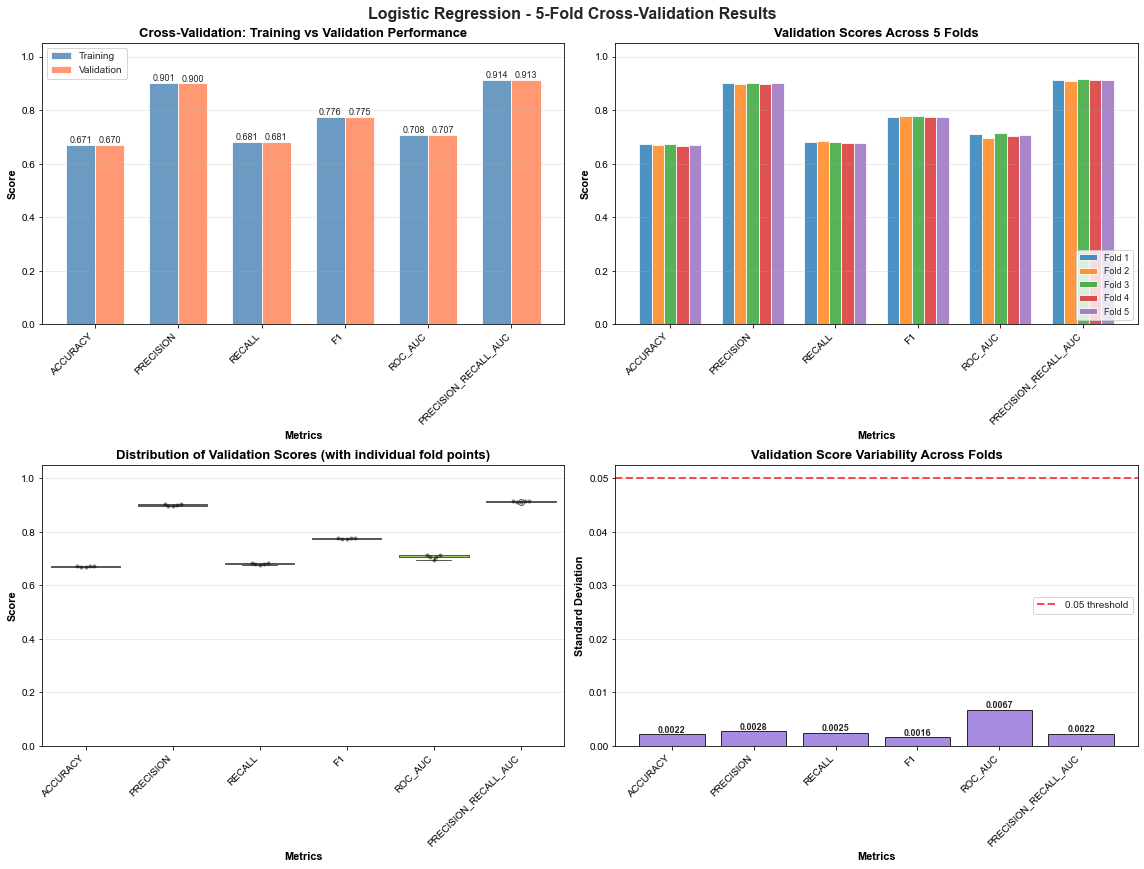


VISUALIZATION GUIDE

📊 Plot 1 (Top Left): Training vs Validation Performance
   - Shows if model is overfitting (large gap between train and val)
   - Ideally, bars should be similar heights

📊 Plot 2 (Top Right): Scores Across Folds
   - Shows consistency of performance across different data splits
   - Look for consistent heights across folds

📊 Plot 3 (Bottom Left): Score Distribution
   - Box plot shows median, quartiles, and outliers
   - Points show individual fold scores
   - Tighter boxes indicate more stable performance

📊 Plot 4 (Bottom Right): Variability Analysis
   - Shows standard deviation across folds
   - Lower bars = more stable performance
   - Red line at 0.05 is a reference threshold

✓ Visualization complete!


In [37]:
# ============================================================================
# VISUALIZE CROSS-VALIDATION RESULTS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style("whitegrid")

# ============================================================================
# PLOT 1: Metric Comparison (Train vs Validation)
# ============================================================================

ax1 = axes[0, 0]

metrics = list(scoring.keys())
train_means = [cv_results[f'train_{m}'].mean() for m in metrics]
val_means = [cv_results[f'test_{m}'].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, train_means, width, label='Training', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, val_means, width, label='Validation', alpha=0.8, color='coral')

ax1.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax1.set_ylabel('Score', fontweight='bold', fontsize=11)
ax1.set_title('Cross-Validation: Training vs Validation Performance', fontweight='bold', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels([m.upper() for m in metrics], rotation=45, ha='right')
ax1.legend()
ax1.set_ylim([0, 1.05])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# ============================================================================
# PLOT 2: Validation Scores Across Folds
# ============================================================================

ax2 = axes[0, 1]

fold_data = []
for metric_name in scoring.keys():
    val_scores = cv_results[f'test_{metric_name}']
    for fold_idx, score in enumerate(val_scores, 1):
        fold_data.append({
            'Metric': metric_name.upper(),
            'Fold': f'Fold {fold_idx}',
            'Score': score
        })

fold_df = pd.DataFrame(fold_data)

# Create grouped bar chart
metrics_list = [m.upper() for m in scoring.keys()]
fold_labels = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(len(metrics_list))
width = 0.15

for i, fold in enumerate(fold_labels):
    fold_scores = fold_df[fold_df['Fold'] == fold]['Score'].values
    offset = (i - 2) * width
    ax2.bar(x + offset, fold_scores, width, label=fold, alpha=0.8)

ax2.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax2.set_ylabel('Score', fontweight='bold', fontsize=11)
ax2.set_title('Validation Scores Across 5 Folds', fontweight='bold', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_list, rotation=45, ha='right')
ax2.legend(loc='lower right', fontsize=9)
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# ============================================================================
# PLOT 3: Box Plot of Validation Scores
# ============================================================================

ax3 = axes[1, 0]

box_data = []
for metric_name in scoring.keys():
    val_scores = cv_results[f'test_{metric_name}']
    for score in val_scores:
        box_data.append({
            'Metric': metric_name.upper(),
            'Score': score
        })

box_df = pd.DataFrame(box_data)

# Create box plot
sns.boxplot(data=box_df, x='Metric', y='Score', ax=ax3, palette='Set2')
sns.swarmplot(data=box_df, x='Metric', y='Score', ax=ax3, color='black', alpha=0.5, size=4)

ax3.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax3.set_ylabel('Score', fontweight='bold', fontsize=11)
ax3.set_title('Distribution of Validation Scores (with individual fold points)', fontweight='bold', fontsize=13)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.set_ylim([0, 1.05])
ax3.grid(axis='y', alpha=0.3)

# ============================================================================
# PLOT 4: Standard Deviation Comparison
# ============================================================================

ax4 = axes[1, 1]

val_stds = [cv_results[f'test_{m}'].std() for m in metrics]

bars = ax4.bar(metrics_list, val_stds, alpha=0.8, color='mediumpurple', edgecolor='black')
ax4.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax4.set_ylabel('Standard Deviation', fontweight='bold', fontsize=11)
ax4.set_title('Validation Score Variability Across Folds', fontweight='bold', fontsize=13)
ax4.set_xticklabels(metrics_list, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=0.05, color='red', linestyle='--', linewidth=2, alpha=0.7, label='0.05 threshold')
ax4.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle('Logistic Regression - 5-Fold Cross-Validation Results', 
             fontsize=16, fontweight='bold', y=1.002)
plt.subplots_adjust(top=0.96)
plt.show()

print("\n" + "="*80)
print("VISUALIZATION GUIDE")
print("="*80)
print("\n📊 Plot 1 (Top Left): Training vs Validation Performance")
print("   - Shows if model is overfitting (large gap between train and val)")
print("   - Ideally, bars should be similar heights")

print("\n📊 Plot 2 (Top Right): Scores Across Folds")
print("   - Shows consistency of performance across different data splits")
print("   - Look for consistent heights across folds")

print("\n📊 Plot 3 (Bottom Left): Score Distribution")
print("   - Box plot shows median, quartiles, and outliers")
print("   - Points show individual fold scores")
print("   - Tighter boxes indicate more stable performance")

print("\n📊 Plot 4 (Bottom Right): Variability Analysis")
print("   - Shows standard deviation across folds")
print("   - Lower bars = more stable performance")
print("   - Red line at 0.05 is a reference threshold")

print("\n✓ Visualization complete!")

CONFUSION MATRIX ANALYSIS

⚙️ Generating predictions using 5-fold cross-validation...
(This ensures we get predictions for all training samples)
✓ Predictions generated!

📊 Computing confusion matrix...

Confusion Matrix Values:
  True Negatives (TN):  10,635
  False Positives (FP): 6,543
  False Negatives (FN): 27,735
  True Positives (TP):  59,073

DETAILED METRIC BREAKDOWN

✓ Accuracy:    0.6704 = (TP + TN) / Total = (59,073 + 10,635) / 103,986
✓ Precision:   0.9003 = TP / (TP + FP) = 59,073 / (59,073 + 6,543)
✓ Recall:      0.6805 = TP / (TP + FN) = 59,073 / (59,073 + 27,735)
✓ Specificity: 0.6191 = TN / (TN + FP) = 10,635 / (10,635 + 6,543)
✓ F1-Score:    0.7751 = 2 * (Precision * Recall) / (Precision + Recall)

🔍 WHY IS PRECISION SO HIGH?

Precision = 0.9003 means:
  ✓ Out of 65,616 predictions of class 1 (positive):
    - 59,073 were CORRECT (True Positives)
    - 6,543 were WRONG (False Positives)
  ✓ So 90.03% of positive predictions were correct

Recall = 0.6805 means:
  ✓ Ou

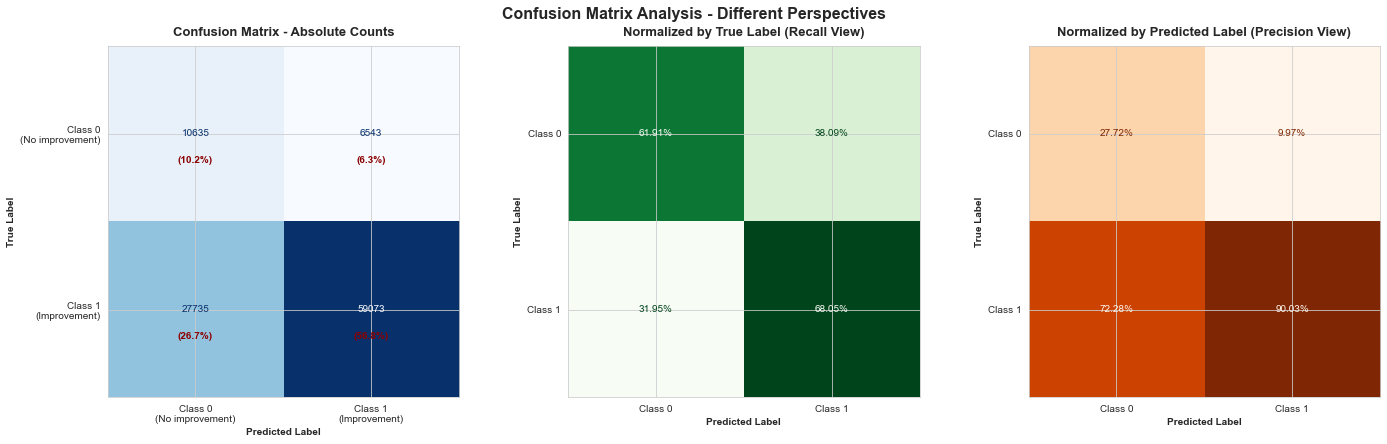


🎯 DECISION THRESHOLD ANALYSIS

Prediction probability statistics:
  Mean probability for class 1: 0.5452
  Median probability for class 1: 0.5661
  Min probability: 0.0094
  Max probability: 0.9233

Predictions at different thresholds:
  Threshold 0.3: 93,616 predictions (90.0%)
  Threshold 0.4: 82,332 predictions (79.2%)
  Threshold 0.5: 65,616 predictions (63.1%)
  Threshold 0.6: 44,309 predictions (42.6%)
  Threshold 0.7: 21,079 predictions (20.3%)

💡 RECOMMENDATION:
  If you want to balance precision and recall:
    → Consider lowering the decision threshold (e.g., 0.3 or 0.4)
    → This will increase recall but decrease precision
  If high precision is important (minimize false alarms):
    → Keep the current threshold (0.5) or increase it

✓ CONFUSION MATRIX ANALYSIS COMPLETE


In [38]:
# ============================================================================
# CONFUSION MATRIX ANALYSIS - UNDERSTANDING HIGH PRECISION
# ============================================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

# ============================================================================
# 1. GET PREDICTIONS FROM CROSS-VALIDATION
# ============================================================================

print("\n⚙️ Generating predictions using 5-fold cross-validation...")
print("(This ensures we get predictions for all training samples)")

# Use cross_val_predict to get out-of-fold predictions
y_pred = cross_val_predict(
    estimator=lr_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv,
    n_jobs=-1
)

# Also get probability predictions
y_pred_proba = cross_val_predict(
    estimator=lr_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]  # Get probability for positive class

print("✓ Predictions generated!")

# ============================================================================
# 2. COMPUTE CONFUSION MATRIX
# ============================================================================

print("\n📊 Computing confusion matrix...")

cm = confusion_matrix(y_train, y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Values:")
print(f"  True Negatives (TN):  {tn:,}")
print(f"  False Positives (FP): {fp:,}")
print(f"  False Negatives (FN): {fn:,}")
print(f"  True Positives (TP):  {tp:,}")

# ============================================================================
# 3. CALCULATE DETAILED METRICS
# ============================================================================

print("\n" + "="*80)
print("DETAILED METRIC BREAKDOWN")
print("="*80)

# Calculate metrics manually for transparency
total = tn + fp + fn + tp
accuracy = (tp + tn) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n✓ Accuracy:    {accuracy:.4f} = (TP + TN) / Total = ({tp:,} + {tn:,}) / {total:,}")
print(f"✓ Precision:   {precision:.4f} = TP / (TP + FP) = {tp:,} / ({tp:,} + {fp:,})")
print(f"✓ Recall:      {recall:.4f} = TP / (TP + FN) = {tp:,} / ({tp:,} + {fn:,})")
print(f"✓ Specificity: {specificity:.4f} = TN / (TN + FP) = {tn:,} / ({tn:,} + {fp:,})")
print(f"✓ F1-Score:    {f1:.4f} = 2 * (Precision * Recall) / (Precision + Recall)")

# ============================================================================
# 4. EXPLAIN HIGH PRECISION
# ============================================================================

print("\n" + "="*80)
print("🔍 WHY IS PRECISION SO HIGH?")
print("="*80)

print(f"\nPrecision = {precision:.4f} means:")
print(f"  ✓ Out of {tp + fp:,} predictions of class 1 (positive):")
print(f"    - {tp:,} were CORRECT (True Positives)")
print(f"    - {fp:,} were WRONG (False Positives)")
print(f"  ✓ So {(tp/(tp+fp)*100):.2f}% of positive predictions were correct")

print(f"\nRecall = {recall:.4f} means:")
print(f"  ✓ Out of {tp + fn:,} actual class 1 samples:")
print(f"    - {tp:,} were CAUGHT by the model (True Positives)")
print(f"    - {fn:,} were MISSED by the model (False Negatives)")
print(f"  ✓ So the model caught {(tp/(tp+fn)*100):.2f}% of all positive cases")

print("\n💡 KEY INSIGHT:")
if precision > 0.90:
    print(f"  Your model is VERY CONSERVATIVE (precision={precision:.4f})")
    print(f"  → It only predicts class 1 when it's very confident")
    print(f"  → This means few False Positives ({fp:,}), leading to high precision")
    print(f"  → But it also means more False Negatives ({fn:,}), leading to lower recall")
    print(f"\n  This is likely due to:")
    print(f"    1. Class weights making the model cautious about predicting minority class")
    print(f"    2. The severe class imbalance (5:1 ratio)")
    print(f"    3. The model's default decision threshold (0.5)")
elif precision > 0.80:
    print(f"  Your model balances precision and recall fairly well")
else:
    print(f"  Your model predicts class 1 more liberally")

# Calculate prediction distribution
pred_class_1_count = (y_pred == 1).sum()
pred_class_0_count = (y_pred == 0).sum()
actual_class_1_count = (y_train == 1).sum()
actual_class_0_count = (y_train == 0).sum()

print(f"\n📊 PREDICTION DISTRIBUTION:")
print(f"  Actual:    Class 0: {actual_class_0_count:,} ({actual_class_0_count/len(y_train)*100:.1f}%) | Class 1: {actual_class_1_count:,} ({actual_class_1_count/len(y_train)*100:.1f}%)")
print(f"  Predicted: Class 0: {pred_class_0_count:,} ({pred_class_0_count/len(y_pred)*100:.1f}%) | Class 1: {pred_class_1_count:,} ({pred_class_1_count/len(y_pred)*100:.1f}%)")

if pred_class_1_count < actual_class_1_count * 0.9:
    print(f"\n  ⚠️ Model is under-predicting class 1!")
    print(f"     Predicted {pred_class_1_count:,} but actual has {actual_class_1_count:,}")
    print(f"     This explains high precision but lower recall")

# ============================================================================
# 5. VISUALIZE CONFUSION MATRICES
# ============================================================================

print("\n📊 Generating confusion matrix visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Absolute counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0\n(No improvement)', 'Class 1\n(Improvement)'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix - Absolute Counts', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# Add annotations with percentages
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = (count / total) * 100
        axes[0].text(j, i + 0.15, f'({pct:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

# Plot 2: Normalized by row (recall view)
cm_recall = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_recall, display_labels=['Class 0', 'Class 1'])
disp2.plot(ax=axes[1], cmap='Greens', values_format='.2%', colorbar=False)
axes[1].set_title('Normalized by True Label (Recall View)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontweight='bold')
axes[1].set_ylabel('True Label', fontweight='bold')

# Plot 3: Normalized by column (precision view)
cm_precision = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_precision, display_labels=['Class 0', 'Class 1'])
disp3.plot(ax=axes[2], cmap='Oranges', values_format='.2%', colorbar=False)
axes[2].set_title('Normalized by Predicted Label (Precision View)', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Predicted Label', fontweight='bold')
axes[2].set_ylabel('True Label', fontweight='bold')

plt.tight_layout()
plt.suptitle('Confusion Matrix Analysis - Different Perspectives', fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.93)
plt.show()

# ============================================================================
# 6. PREDICTION THRESHOLD ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("🎯 DECISION THRESHOLD ANALYSIS")
print("="*80)

# Analyze prediction probabilities
print(f"\nPrediction probability statistics:")
print(f"  Mean probability for class 1: {y_pred_proba.mean():.4f}")
print(f"  Median probability for class 1: {np.median(y_pred_proba):.4f}")
print(f"  Min probability: {y_pred_proba.min():.4f}")
print(f"  Max probability: {y_pred_proba.max():.4f}")

# Count predictions at different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"\nPredictions at different thresholds:")
for thresh in thresholds:
    pred_at_thresh = (y_pred_proba >= thresh).sum()
    pct = (pred_at_thresh / len(y_pred_proba)) * 100
    print(f"  Threshold {thresh}: {pred_at_thresh:,} predictions ({pct:.1f}%)")

print("\n💡 RECOMMENDATION:")
print("  If you want to balance precision and recall:")
print("    → Consider lowering the decision threshold (e.g., 0.3 or 0.4)")
print("    → This will increase recall but decrease precision")
print("  If high precision is important (minimize false alarms):")
print("    → Keep the current threshold (0.5) or increase it")

print("\n" + "="*80)
print("✓ CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*80)

In [ ]:
# ============================================================================
# 8. DECISION TREE FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("DECISION TREE FEATURE IMPORTANCE")
print("="*80)

# Train final model on all data to get feature importance
dt_final = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=15,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42,
    criterion='gini'
)

print("\n⚙️ Training Decision Tree on all training data...")
dt_final.fit(X_train_final_encoded, y_train)
print("✓ Model trained!")

# Get feature importance
feature_importance = dt_final.feature_importances_
feature_names = X_train_final_encoded.columns.tolist()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n" + "="*80)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*80)

top_20 = importance_df.head(20)
print("\n" + top_20.to_string(index=False))

# Visualize top 20 features
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top 20 features
ax1 = axes[0]
top_20_sorted = top_20.sort_values('Importance', ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_20_sorted)))
bars = ax1.barh(range(len(top_20_sorted)), top_20_sorted['Importance'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(top_20_sorted)))
ax1.set_yticklabels(top_20_sorted['Feature'], fontsize=9)
ax1.set_xlabel('Importance', fontweight='bold', fontsize=11)
ax1.set_title('Top 20 Most Important Features (Decision Tree)', fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_20_sorted['Importance'])):
    ax1.text(val, i, f' {val:.4f}', va='center', fontsize=8)

# Plot 2: Cumulative importance
ax2 = axes[1]
cumsum = importance_df['Importance'].cumsum()
ax2.plot(range(len(cumsum)), cumsum, linewidth=3, color='steelblue')
ax2.fill_between(range(len(cumsum)), cumsum, alpha=0.3, color='steelblue')
ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80% threshold')
ax2.axhline(y=0.9, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Features', fontweight='bold', fontsize=11)
ax2.set_ylabel('Cumulative Importance', fontweight='bold', fontsize=11)
ax2.set_title('Cumulative Feature Importance', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

# Find how many features for 80% and 90%
n_80 = (cumsum >= 0.8).argmax() + 1
n_90 = (cumsum >= 0.9).argmax() + 1
ax2.text(0.6, 0.3, f'{n_80} features = 80%\n{n_90} features = 90%',
        transform=ax2.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHTS:")
print(f"  • {n_80} features account for 80% of importance")
print(f"  • {n_90} features account for 90% of importance")
print(f"  • Total features: {len(feature_names)}")
print(f"  • Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")

print("\n" + "="*80)
print("✓ DECISION TREE ANALYSIS COMPLETE")
print("="*80)